# Статистический анализ бинарных файлов в целях обнаружения  malware

### Загружаем датасет


In [1]:
!pip install pefile pandas matplotlib jax

/bin/bash: line 1: pip: command not found


In [2]:
!wget https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/data.csv

--2026-04-01 16:57:53--  https://raw.githubusercontent.com/james116blue/game_theory_course/refs/heads/spring-2026/malware/data.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 50668563 (48M) [text/plain]
Saving to: ‘data.csv.1’

data.csv.1          100%[===================>]  48.32M  39.1MB/s    in 1.2s    

2026-04-01 16:57:56 (39.1 MB/s) - ‘data.csv.1’ saved [50668563/50668563]



In [6]:
import pandas as pd  # pandas для рабботы с датасетом
dataset = pd.read_csv('data.csv', sep='|')
# Поменяем метки местами
dataset["malware"] = dataset["legitimate"].replace({0:1, 1:0})  # 1 если вредонос
# Отбор признаков
dataset = dataset.drop(['legitimate'],axis=1)  # у нас уже есть столбец malware
dataset = dataset.drop(['Name','md5'],axis=1)   # Отброс данных признаков типа object. Модель будет принимать только признаки типа int и float
X = dataset.drop(['malware'],axis=1).values# Матрица признаков объектов обучающей выборки
y = dataset['malware'].values # Целевая переменная

## JAX: Autograd и XLA для высокопроизводительных вычислений

**JAX** — это библиотека для машинного обучения и научных вычислений, разработанная Google Research. Она объединяет возможности автоматического дифференцирования (Autograd) и компиляции для ускорителей (XLA), предоставляя знакомый API, похожий на NumPy.

### Ключевые особенности:

1.  **Jit-компиляция (`jax.jit`):** Компилирует Python-функции в эффективные машинные графы XLA. Это позволяет коду работать невероятно быстро на CPU, GPU и TPU без изменения синтаксиса.
2.  **Автоматическое дифференцирование (`jax.grad`):** Позволяет вычислять градиенты функций любой сложности (включая циклы и условия) одной строкой кода. Поддерживает прямое (forward) и обратное (reverse) распространение.
3.  **Векторизация (`jax.vmap`):** Автоматическая векторизация функций. Упрощает обработку батчей данных без необходимости вручную писать циклы или сложную индексацию.
4.  **Функциональный подход:** JAX требует написания функционально чистого кода (без побочных эффектов), что делает преобразования и параллелизм предсказуемыми и эффективными.

In [70]:

import jax
import jax.numpy as jnp # синтаксис numpy
from jax import jit, vmap, grad
jnp.set_printoptions(suppress=True)
jnp.set_printoptions(precision=4)
# конверитуем numpy массивы в jax массивы
X = jnp.asarray(X) 
y = jnp.asarray(y)
print(X.shape, y.shape)

(138047, 54) (138047,)


In [10]:
# Разбивка данных (70% - обучающие and 30% - тестовые)
from sklearn.model_selection import train_test_split # Функция для разделения выборки на обучающую и тестовую
X_train, X_test, y_train, y_test = train_test_split(X, y ,test_size=0.3, stratify = y)

In [ ]:
#стандартизация признакового пространства
x_mean = X_train.mean(axis=0)
x_std = X_train.std(axis=0)
X_train = (X_train - x_mean) / x_std
X_test = (X_test - x_mean) / x_std
# проверяем , что массивы остались нужного формата
assert isinstance(X_train, jax.Array)  #JAX returns True both inside and outside traced functions.
assert isinstance(y_train, jax.Array)

### Линейный классификатор

In [45]:
def linear(X, w, b):
    return  X @ w + b
def softmax(z):
    return jnp.exp(z) / jnp.sum(jnp.exp(z), axis=1, keepdims=True)

def model(X, w, b):
    return softmax(linear (X,w,b))

In [63]:
key = jax.random.PRNGKey(0)
key, w_key, b_key = jax.random.split(key, 3)
k = 2 
w = jax.random.normal(w_key, (X_train.shape[1], k)) * 10**-8 
b = jax.random.normal(b_key, (k,))  * 10**-8
print(w.shape, b.shape)

(54, 2) (2,)


In [46]:
#forward
y_hat = model(X_train[:3], w, b)
y_hat

Array([[0.50000006, 0.5       ],
       [0.5       , 0.5       ],
       [0.5       , 0.50000006]], dtype=float32)

### Функция потерь

Чтобы выбрать один элемент из каждой строки двумерного массива NumPy на основе массива индексов, можно воспользоваться расширенной индексацией NumPy. Ниже показано, как это можно сделать:

### Пример:

```python
import numpy as np

# Пример двумерного массива
array = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

# Массив индексов (один индекс для каждой строки)
indices = np.array([0, 2, 1])

# Выбираем один элемент из каждой строки на основе индексов
selected_elements = array[np.arange(array.shape[0]), indices]

print(selected_elements)
```

### Объяснение:
1. `np.arange(array.shape[0])` генерирует массив индексов строк `[0, 1, 2]` (при условии, что массив имеет 3 строки).
2. `indices` — это массив индексов столбцов `[0, 2, 1]` для каждой строки.
3. `array[np.arange(array.shape[0]), indices]` выбирает элемент в указанной строке и столбце для каждой строки.

### Вывод:
```
[1 6 8]
```

### Разбор:
- Для строки 0 выбирается элемент в столбце 0: `1`.
- Для строки 1 выбирается элемент в столбце 2: `6`.
- Для строки 2 выбирается элемент в столбце 1: `8`.

Этот метод эффективно работает с любым двумерным массивом NumPy и соответствующим ему массивом индексов.

In [47]:
# Training loss is the negative log-likelihood of the training examples.
def log_loss(y_hat, y):
    label_probs =  y_hat[jnp.arange(y_hat.shape[0]), y] + 10**-8 # add 10**8 to exclude log(0)
    return jnp.mean(-jnp.log(label_probs))

In [49]:
loss_fn = lambda w, b: log_loss(model(X_train, w, b), y_train)
#jitted version
loss_fn_jitted = jax.jit(loss_fn)
#check with initial w and b
loss_fn(w, b), loss_fn_jitted(w, b)

(Array(0.69314706, dtype=float32), Array(0.6931476, dtype=float32))

### Градиентный спуск

In [64]:
w_grad, b_grad = grad(loss_fn, argnums=(0,1))(w, b)
w_grad[:3], b_grad[:3]

(Array([[-0.2510248 ,  0.25102478],
        [-0.2510036 ,  0.25100356],
        [-0.10286714,  0.10286713]], dtype=float32),
 Array([ 0.2006586, -0.2006586], dtype=float32))

In [65]:
#forward and backward simultaneously
loss_value, (w_grad, b_grad) = jax.value_and_grad(loss_fn_jitted, (0, 1))(w, b)
print('loss value', loss_value)
print('w_grad shape', w_grad.shape)
#jitted version 

loss value 0.69314706
w_grad shape (54, 2)


In [67]:
#gradient descent
jax.config.update("jax_debug_nans", False)
alpha = 0.01
key, w_key, b_key = jax.random.split(key, 3)
w = jax.random.normal(w_key, (X_train.shape[1], k)) * 10**-8 
b = jax.random.normal(b_key, (k,))  * 10**-8
loss_values = [] #stats for plotting
for i in range(1 * 10**4):
    loss_value, (w_grad, b_grad) = jax.value_and_grad(loss_fn_jitted, (0, 1))(w, b)
    w = w - alpha * w_grad
    b = b -alpha * b_grad
    loss_values.append(loss_value)

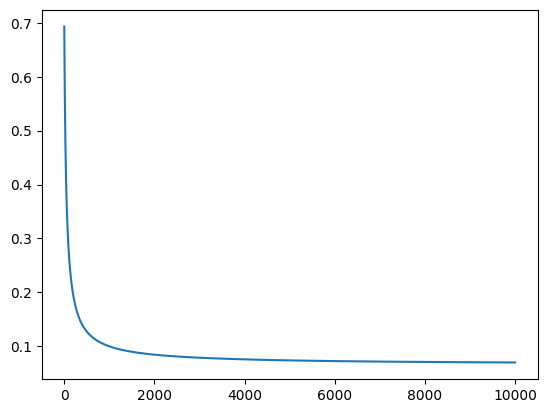

In [68]:
import matplotlib.pyplot as plt
plt.plot(loss_values)
plt.show()

In [72]:
y_pred = model(X_test, w, b) 
y_pred[:5], y_test[:5]

(Array([[1.    , 0.    ],
        [0.9999, 0.0001],
        [0.0042, 0.9958],
        [0.9981, 0.0019],
        [0.    , 1.    ]], dtype=float32),
 Array([0, 0, 1, 0, 1], dtype=int32))